In [167]:
import pandas as pd
df=pd.read_csv('merged_dataset.csv')
coords = df[['complaint_lat', 'complaint_lon']].values

In [168]:
import sys
!{sys.executable} -m pip install plotly nbformat


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip


In [175]:
def assign_neighborhood(lat, lon):
    # THE LOOP (Downtown core, North of Roosevelt)
    if (41.867 < lat <= 41.891) and (-87.640 <= lon <= -87.610):
        return "The Loop"
    
    # NEAR SOUTH SIDE (South Loop/Museum Campus, South of Roosevelt)
    elif (41.845 <= lat <= 41.867) and (-87.640 <= lon <= -87.610):
        return "Near South Side"
    
    # NEAR NORTH SIDE (River North/Magnificent Mile)
    elif (41.891 < lat <= 41.910) and (-87.650 <= lon <= -87.610):
        return "Near North Side"
    
    # LINCOLN PARK
    elif (41.910 < lat <= 41.940) and (-87.660 <= lon <= -87.620):
        return "Lincoln Park"
    
    # LOGAN SQUARE
    elif (41.910 <= lat <= 41.935) and (-87.730 <= lon <= -87.680):
        return "Logan Square"
    
    # WEST TOWN (Wicker Park/Bucktown)
    elif (41.885 <= lat <= 41.910) and (-87.700 <= lon <= -87.650):
        return "West Town"
    
    # NEAR WEST SIDE (West Loop/UIC)
    elif (41.865 <= lat <= 41.885) and (-87.680 <= lon <= -87.635):
        return "Near West Side"
    
    # HYDE PARK
    elif (41.780 <= lat <= 41.805) and (-87.605 <= lon <= -87.575):
        return "Hyde Park"
    
    # ENGLEWOOD
    elif (41.760 <= lat <= 41.795) and (-87.670 <= lon <= -87.625):
        return "Englewood"
    
    # BRIDGEPORT
    elif (41.820 <= lat <= 41.850) and (-87.665 <= lon <= -87.635):
        return "Bridgeport"

    return "Other/Residential"

df['neighborhood'] = df.apply(lambda x: assign_neighborhood(x['complaint_lat'], x['complaint_lon']), axis=1)
df_neighborhoods = df[df['neighborhood'] != "Other/Residential"].copy()

/var/folders/_t/m095hk5n69d41f43lgwgshd40000gn/T/ipykernel_44962/2583426858.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Neighborhood', y='Complaint_Count', data=neigh_stats, ax=ax1, palette='coolwarm', label='Number of Complaints')
/var/folders/_t/m095hk5n69d41f43lgwgshd40000gn/T/ipykernel_44962/2583426858.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


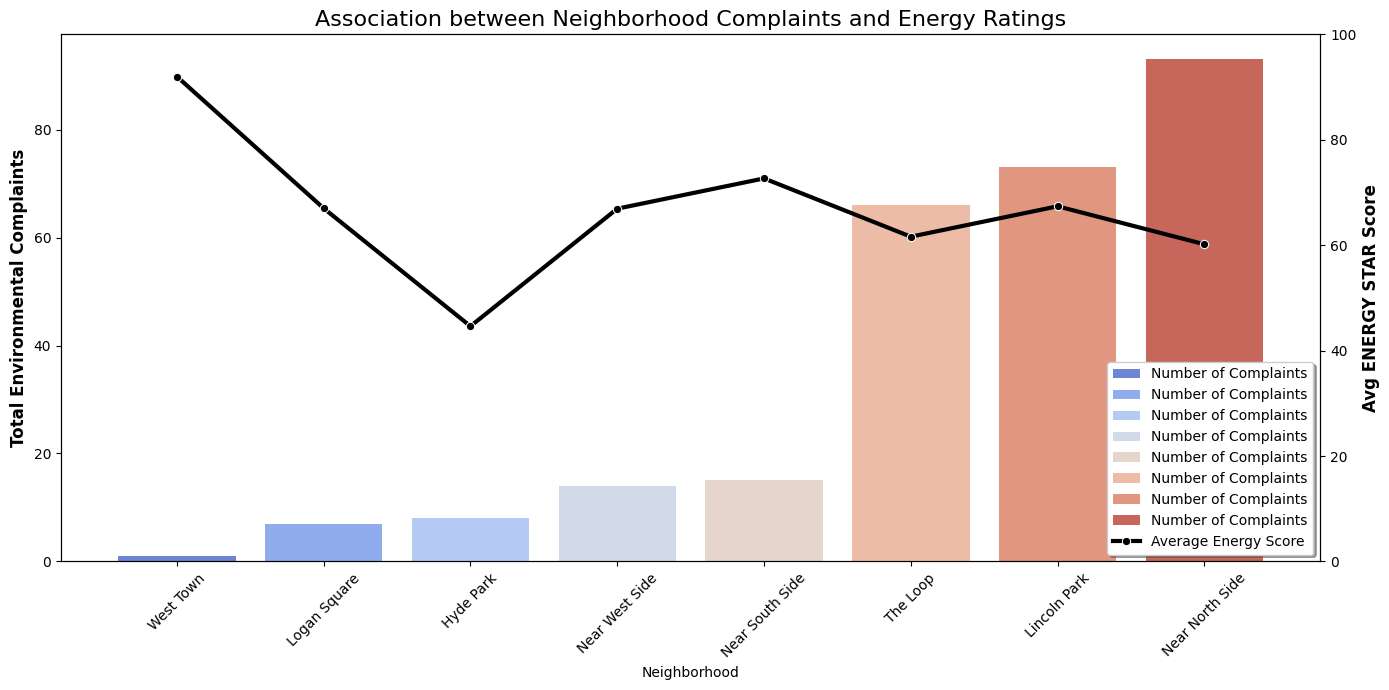

In [177]:
neigh_stats = df_neighborhoods.groupby('neighborhood').agg({
    'ADDRESS': 'count',
    'ENERGY STAR Score': 'mean'
}).reset_index()

neigh_stats.columns = ['Neighborhood', 'Complaint_Count', 'Avg_Energy_Score']


neigh_stats = neigh_stats.sort_values('Complaint_Count')


import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(14, 7))


sns.barplot(x='Neighborhood', y='Complaint_Count', data=neigh_stats, ax=ax1, palette='coolwarm', label='Number of Complaints')
ax1.set_ylabel('Total Environmental Complaints', fontsize=12, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


ax2 = ax1.twinx()
sns.lineplot(x='Neighborhood', y='Avg_Energy_Score', data=neigh_stats, ax=ax2, color='black', marker='o', linewidth=3, label='Average Energy Score')
ax2.set_ylabel('Avg ENERGY STAR Score', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)


lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='lower right', frameon=True, shadow=True)

plt.title('Association between Neighborhood Complaints and Energy Ratings', fontsize=16)
plt.tight_layout()
plt.show()

In [178]:
import plotly.express as px

fig = px.scatter_mapbox(
    df_neighborhoods, 
    lat="complaint_lat", 
    lon="complaint_lon", 
    color="neighborhood",      
    hover_name="ADDRESS",      
    hover_data={
        "ENERGY STAR Score": True, 
        "neighborhood": False,
        "complaint_lat": False,
        "complaint_lon": False
    },
    zoom=10.5,
    height=800,
    title="Building Complaints Grouped by Defined Neighborhood Boundaries"
)

fig.update_layout(
    mapbox_style="carto-positron", 
    margin={"r":0,"t":50,"l":0,"b":0},
    legend_title_text='Neighborhood'
)

fig.show()

/var/folders/_t/m095hk5n69d41f43lgwgshd40000gn/T/ipykernel_44962/4087543586.py:3: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [179]:
neighborhood_counts = df_neighborhoods['neighborhood'].value_counts().reset_index()
neighborhood_counts.columns = ['Neighborhood', 'Total_Complaints']


neighborhood_counts = neighborhood_counts.sort_values(by='Total_Complaints', ascending=False)

print(neighborhood_counts)

      Neighborhood  Total_Complaints
0  Near North Side                93
1     Lincoln Park                73
2         The Loop                66
3  Near South Side                15
4   Near West Side                14
5        Hyde Park                 8
6     Logan Square                 7
7        West Town                 1


/var/folders/_t/m095hk5n69d41f43lgwgshd40000gn/T/ipykernel_44962/4254316788.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Complaints', y='Neighborhood', data=neigh_stats, ax=ax1, palette='Blues_r')
/var/folders/_t/m095hk5n69d41f43lgwgshd40000gn/T/ipykernel_44962/4254316788.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Energy_Score', y='Neighborhood', data=neigh_stats, ax=ax2, palette='YlGn')


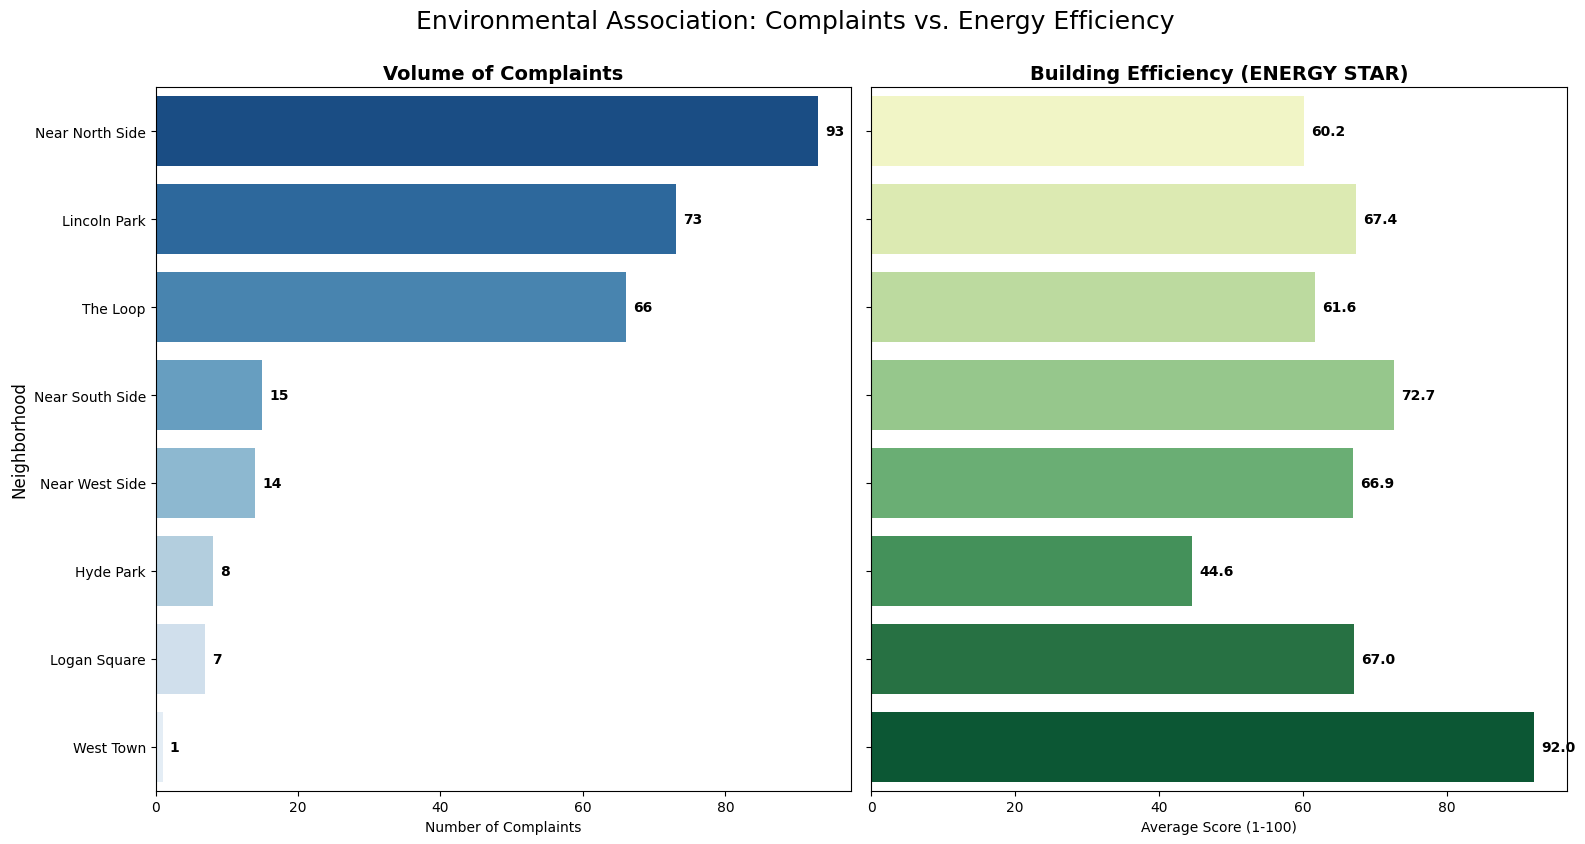

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns

neigh_stats = df_neighborhoods.groupby('neighborhood').agg({
    'ADDRESS': 'count',
    'ENERGY STAR Score': 'mean'
}).reset_index()

neigh_stats.columns = ['Neighborhood', 'Total_Complaints', 'Avg_Energy_Score']
neigh_stats = neigh_stats.sort_values('Total_Complaints', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

sns.barplot(x='Total_Complaints', y='Neighborhood', data=neigh_stats, ax=ax1, palette='Blues_r')
ax1.set_title('Volume of Complaints', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Complaints')
ax1.set_ylabel('Neighborhood', fontsize=12)

for i, count in enumerate(neigh_stats['Total_Complaints']):
    ax1.text(count + 1, i, str(int(count)), va='center', color='black', fontweight='bold')

sns.barplot(x='Avg_Energy_Score', y='Neighborhood', data=neigh_stats, ax=ax2, palette='YlGn')
ax2.set_title('Building Efficiency (ENERGY STAR)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Score (1-100)')
ax2.set_ylabel('') 


for i, score in enumerate(neigh_stats['Avg_Energy_Score']):
    ax2.text(score + 1, i, f"{score:.1f}", va='center', color='black', fontweight='bold')


plt.tight_layout()
plt.suptitle('Environmental Association: Complaints vs. Energy Efficiency', fontsize=18, y=1.05)
plt.show()